In [1]:
import pandas as pd 
import numpy as np

df = pd.read_csv('visual.csv')


print(df.head())

   CustID Premium  Model_Year  Owner_Type  Road side addon  \
0   10000  33,249        2011           1                1   
1   10001  28,102        2013           2                0   
2   10002  30,271        2008           1                0   
3   10003  26,247        2014           2                0   
4   10004  29,665        2005           1                0   

  No Claim bonus discount  Electric add on rate  Company Car Type  \
0                   1,523                   384  Hyundai    Sedan   
1                   1,452                   411  Hyundai    Sedan   
2                   1,367                   317  Hyundai    Sedan   
3                   1,249                   496    Honda    Sedan   
4                   1,310                   447  Hyundai    Sedan   

           RTO  CNGkit     Paymentmode Total IDV  Seats Acquisition Channel  
0          Pen       0  Digital Wallet   714,966      8              Direct  
1  Navi Mumbai       1  Digital Wallet   718,209      6 

C:\Users\thilks\AppData\Local\Temp\ipykernel_11032\259378216.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
df.dtypes

CustID                      int64
Premium                    object
Model_Year                  int64
Owner_Type                  int64
Road side addon             int64
No Claim bonus discount    object
Electric add on rate        int64
Company                    object
Car Type                   object
RTO                        object
CNGkit                      int64
Paymentmode                object
Total IDV                  object
Seats                       int64
Acquisition Channel        object
dtype: object

In [5]:
num_col =['Premium','No Claim bonus discount','Total IDV']

for col in num_col:
    df[col] = df[col].str.replace(',','').astype(float)
print(df.dtypes)



CustID                       int64
Premium                    float64
Model_Year                   int64
Owner_Type                   int64
Road side addon              int64
No Claim bonus discount    float64
Electric add on rate         int64
Company                     object
Car Type                    object
RTO                         object
CNGkit                       int64
Paymentmode                 object
Total IDV                  float64
Seats                        int64
Acquisition Channel         object
dtype: object


In [6]:
sedan = df[(df['Car Type']=='Sedan') & (df['Model_Year']== 2019)]['Total IDV'].median()
Hatchback = df[(df['Car Type']=='HatchBack') & (df['Model_Year']== 2018)]['Total IDV'].median()

diff = Hatchback - sedan

print(diff)

15703.0


C:\Users\thilks\AppData\Local\Temp\ipykernel_11032\145912268.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:blue'` for the same effect.

  sns.barplot(x= 'Paymentmode',y='Premium',hue='Owner_Type',data=df,color = 'blue')


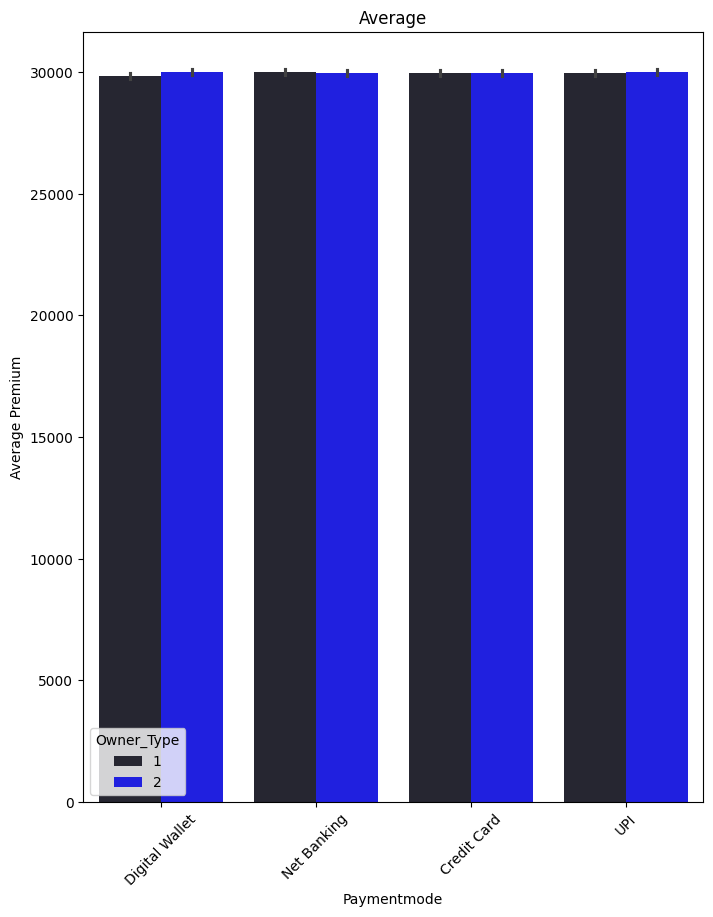

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

avg = df.groupby(['Owner_Type','Paymentmode'])['Premium'].mean()

plt.figure(figsize = (8,10))
sns.barplot(x= 'Paymentmode',y='Premium',hue='Owner_Type',data=df,color = 'blue')
plt.xlabel("Paymentmode")
plt.ylabel('Average Premium')
plt.title("Average")
plt.xticks(rotation=45)
plt.show()

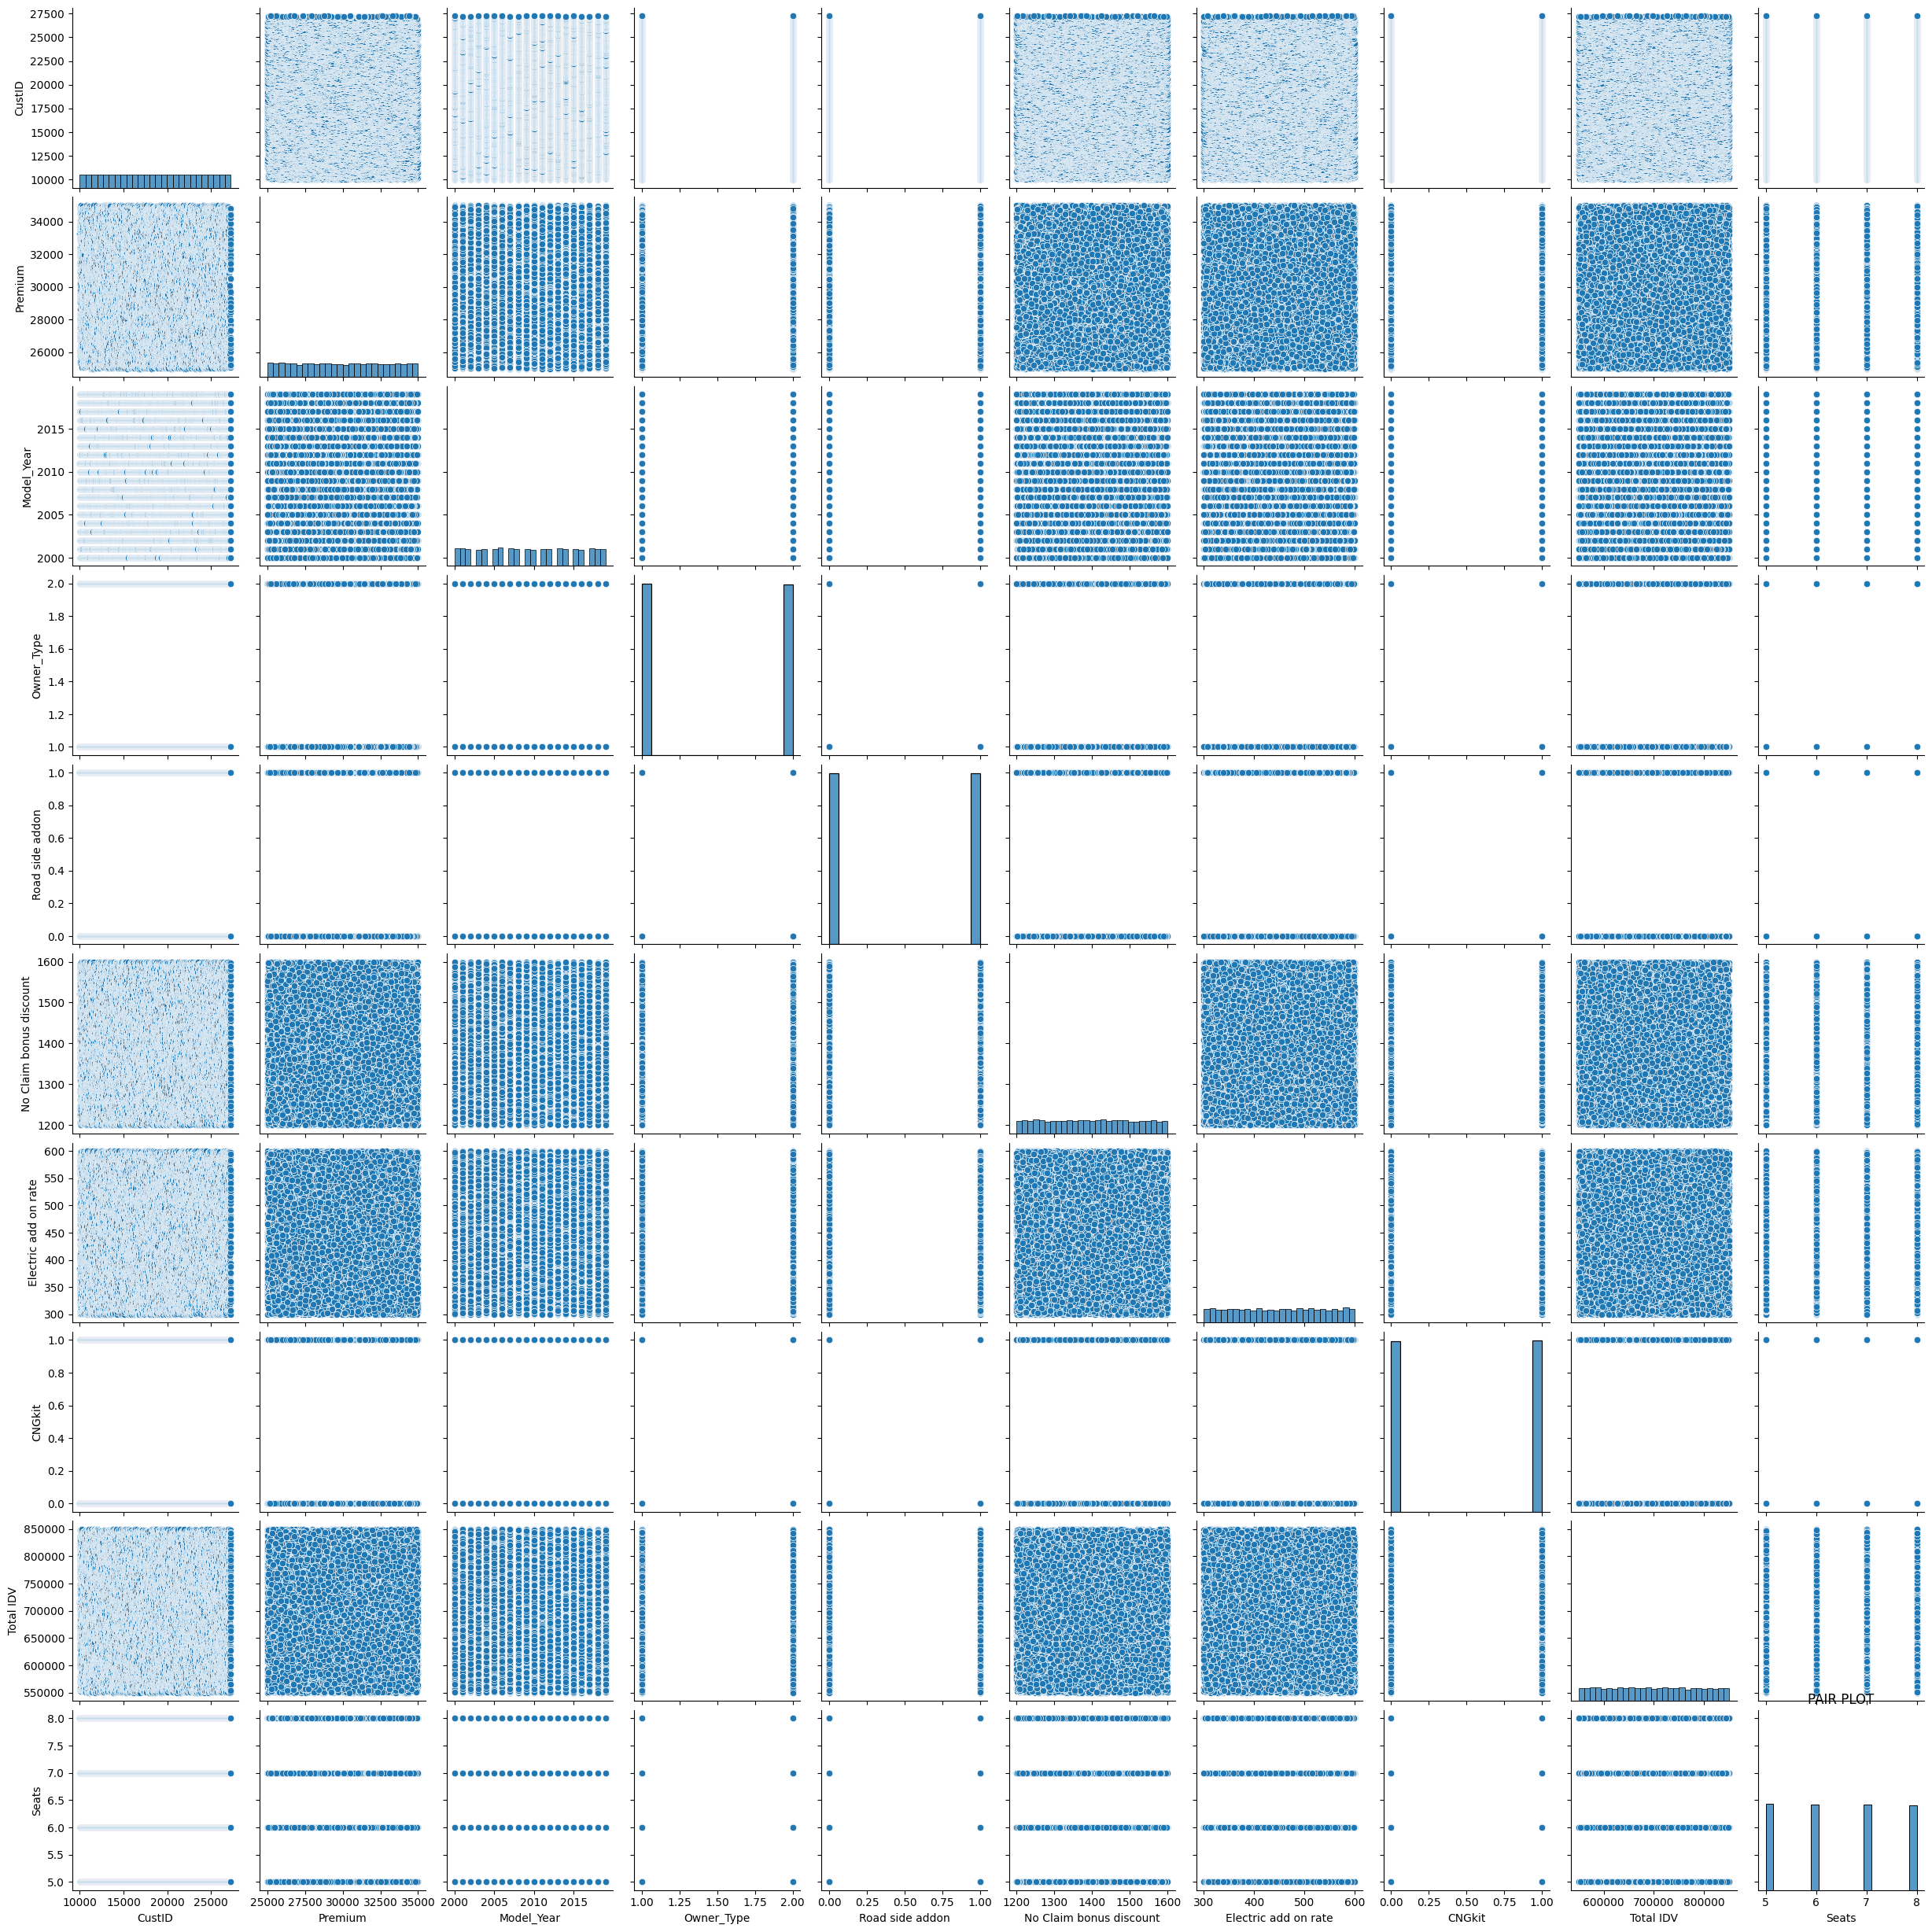

In [20]:
sns.pairplot(df)
plt.title("PAIR PLOT")
plt.show()

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


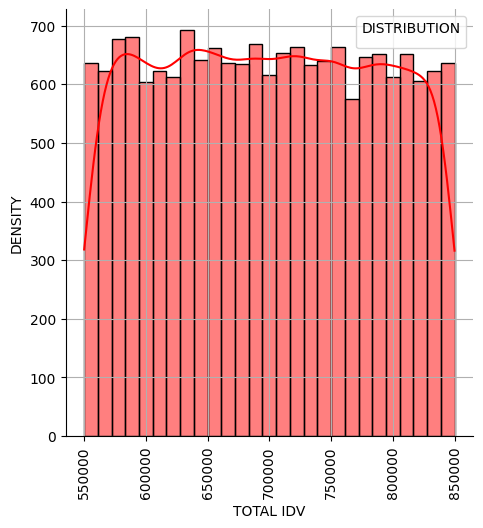

In [25]:
sns.displot(data=df['Total IDV'],kde=True,color = 'red',)
plt.legend(title ="DISTRIBUTION")
plt.xlabel("TOTAL IDV")
plt.ylabel("DENSITY")
plt.xticks(rotation = 90)
plt.grid(True)
plt.show()




Model_Year
2000    403019
2001    404109
2002    381076
2003    365967
2004    384974
2005    386698
2006    416415
2007    393679
2008    382859
2009    380853
2010    369064
2011    387390
2012    387026
2013    403984
2014    388494
2015    392125
2016    370101
2017    398372
2018    388525
2019    380822
Name: Electric add on rate, dtype: int64


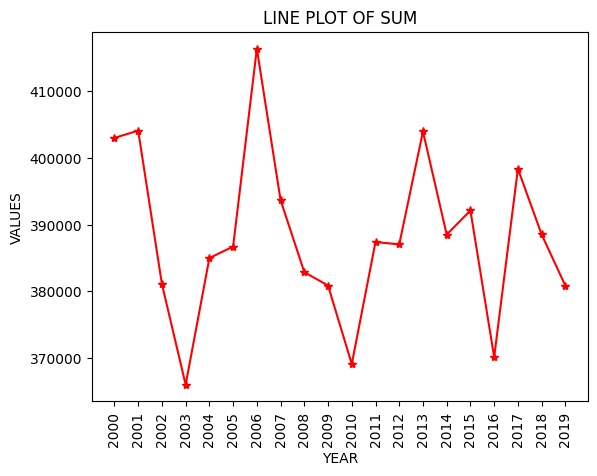

In [31]:
sum_of = df.groupby('Model_Year')['Electric add on rate'].sum()
sum_of.index =sum_of.index.astype(str)
print(sum_of)

plt.plot(sum_of.index,sum_of.values,marker="*",color='red')
plt.title("LINE PLOT OF SUM")
plt.xlabel("YEAR")
plt.ylabel("VALUES")
plt.grid(False)
plt.xticks(rotation=90)
plt.show()

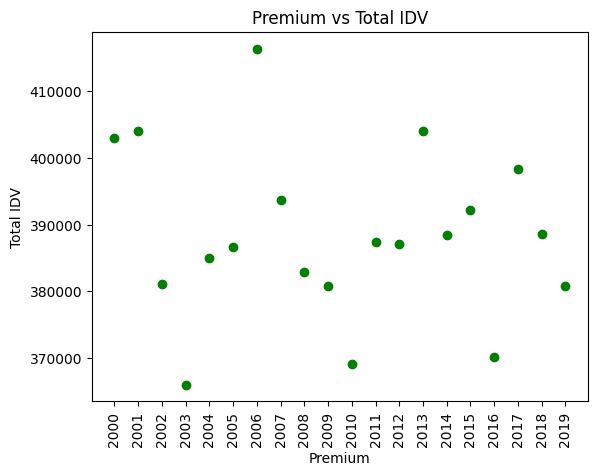

In [33]:
plt.scatter(sum_of.index, sum_of.values,color = 'green')
plt.title('Premium vs Total IDV')
plt.xlabel('Premium')
plt.ylabel('Total IDV')
plt.grid(False)
plt.xticks(rotation=90)
plt.show()